# DNSC 8328 Assignment 3 — Python code

Runs top to bottom in a fresh session on the `hw3-env` kernel (packages in `requirements.txt`),
with `Long_Distance_Carrier Data.xls` in the same folder.

## Setup

In [1]:
import contextlib
import io
import logging
import warnings

warnings.filterwarnings("ignore")                        # tqdm/ipywidgets notice on import

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import bnlearn as bn
import pgmpy
from bnlearn.utils import infer_data_type
from matplotlib.patches import Ellipse
from pgmpy.parameter_estimator import DiscreteBayesianEstimator
from pgmpy.utils import get_state_counts

logging.getLogger("bnlearn").setLevel(logging.WARNING)   # bnlearn logs at INFO to stderr

print("bnlearn", bn.__version__)
print("pgmpy  ", pgmpy.__version__)

bnlearn 1.0.0
pgmpy   1.1.2


In [2]:
SEED = 8328
np.random.seed(SEED)

DATA_FILE = "Long_Distance_Carrier Data.xls"
STATES = {"Y": ["A", "B", "C"], "X1": ["low", "high"],
          "X2": ["low", "high"], "X3": ["low", "high"]}
PROFILE = {"X1": "high", "X2": "low", "X3": "high"}      # customer of B2.3
ALPHA = 12                                               # global precision

M_EDGES = {                                              # candidate models of B4
    "M1": [("Y", "X1"), ("Y", "X2"), ("Y", "X3"), ("X1", "X2"), ("X1", "X3"), ("X2", "X3")],
    "M2": [("Y", "X1"), ("Y", "X2"), ("Y", "X3")],
    "M3": [("Y", "X1"), ("Y", "X2"), ("Y", "X3"), ("X1", "X2")],
    "M4": [("Y", "X1"), ("Y", "X2"), ("Y", "X3"), ("X1", "X3")],
    "M5": [("Y", "X1"), ("Y", "X2"), ("Y", "X3"), ("X2", "X3")],
}
nb_edges = M_EDGES["M2"]                                 # naive Bayes

In [3]:
def quiet(func, *args, **kwargs):
    # run a bnlearn call without its placeholder-CPD printout
    with contextlib.redirect_stdout(io.StringIO()):
        return func(*args, **kwargs)


def load_data(path=DATA_FILE):
    # read the survey sheet; recode Y 1,2,3 -> A,B,C and X 0,1 -> low,high
    df = pd.read_excel(path, sheet_name="Data")
    df["Y"] = df["Y"].map({1: "A", 2: "B", 3: "C"})
    for col in ["X1", "X2", "X3"]:
        df[col] = df[col].map({0: "low", 1: "high"})
    df = df[["Y", "X1", "X2", "X3"]]
    assert df.notna().all().all(), "unmapped codes in the data"
    for col, levels in STATES.items():
        df[col] = pd.Categorical(df[col], categories=levels)
    return df


def free_parameters(edges, states=STATES):
    # sum over nodes of (C_i - 1) * Q_i
    total = 0
    for node, levels in states.items():
        parents = [p for p, c in edges if c == node]
        q = int(np.prod([len(states[p]) for p in parents])) if parents else 1
        total += (len(levels) - 1) * q
    return total


def dir_str(v):
    return "Dir(" + ", ".join(f"{x:g}" for x in v) + ")"


POS = {"Y": (0.5, 0.78), "X1": (0.16, 0.22), "X2": (0.5, 0.22), "X3": (0.84, 0.22)}
LABELS = {"Y": "$Y$", "X1": "$X_1$", "X2": "$X_2$", "X3": "$X_3$"}
NODE_W, NODE_H = 0.19, 0.26


def draw_dag(edges, title=None, ax=None):
    # DAG over Y and the attributes; edges between attributes bend below the row
    if ax is None:
        _, ax = plt.subplots(figsize=(3.6, 2.4))
    for node, (x, y) in POS.items():
        ax.add_patch(Ellipse((x, y), NODE_W, NODE_H, facecolor="white",
                             edgecolor="black", linewidth=0.9, zorder=2))
        ax.text(x, y, LABELS[node], ha="center", va="center", fontsize=11, zorder=3)
    for parent, child in edges:
        curved = parent != "Y"
        ax.annotate("", xy=POS[child], xytext=POS[parent], zorder=1,
                    arrowprops=dict(arrowstyle="-|>", color="black", linewidth=0.9,
                                    mutation_scale=9, shrinkA=13, shrinkB=13,
                                    connectionstyle="arc3,rad=-0.5" if curved else "arc3"))
    if title:
        ax.set_title(title, fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0.02, 0.98)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax

## B1 Exploration

### B1.1 Read and recode the data

In [4]:
data = load_data()
print(len(data), "responses")
data.dtypes

877 responses


Y     category
X1    category
X2    category
X3    category
dtype: object

In [5]:
# bnlearn's discrete/continuous rule (bnlearn.utils.infer_data_type)
raw = pd.read_excel(DATA_FILE, sheet_name="Data")[["Y", "X1", "X2", "X3"]]
print("cardinality threshold:", max(10, int(0.05 * len(raw))))
print("raw integer codes    :", infer_data_type(raw)["dtype"])
print("recoded data         :", infer_data_type(data)["dtype"])
print("X1 stored as float   :", infer_data_type(raw.astype({"X1": float}))["dtype"])

cardinality threshold: 43
raw integer codes    : discrete
recoded data         : discrete
X1 stored as float   : mixed


### B1.2 The four-way contingency table

In [6]:
four_way = (pd.crosstab([data["X1"], data["X2"], data["X3"]], data["Y"])
            .reindex(columns=STATES["Y"]))
four_way["total"] = four_way.sum(axis=1)
four_way

Y                 A    B   C  total
X1   X2   X3                       
low  low  low   113   98  73    284
          high   35   18  17     70
     high low    19    8   7     34
          high   36    9  15     60
high low  low    21   60   5     86
          high   27   66   9    102
     high low     8    8   6     22
          high   74  113  32    219

### B1.3 The cross-tabulations of Y with each X

In [7]:
for col in ["X1", "X2", "X3"]:
    counts = pd.crosstab(data["Y"], data[col])
    props = pd.crosstab(data["Y"], data[col], normalize="columns").round(4)
    print(f"Y by {col}: counts and p(Y | {col})")
    display(pd.concat({"count": counts, "p(Y|x)": props}, axis=1))

Y by X1: counts and p(Y | X1)


count       p(Y|x)        
X1   low high     low    high
Y                            
A    203  130  0.4531  0.3030
B    133  247  0.2969  0.5758
C    112   52  0.2500  0.1212

Y by X2: counts and p(Y | X2)


count       p(Y|x)        
X2   low high     low    high
Y                            
A    196  137  0.3616  0.4090
B    242  138  0.4465  0.4119
C    104   60  0.1919  0.1791

Y by X3: counts and p(Y | X3)


count       p(Y|x)        
X3   low high     low    high
Y                            
A    161  172  0.3779  0.3814
B    174  206  0.4085  0.4568
C     91   73  0.2136  0.1619

### B1.4 Which attribute appears most related to the preferred provider?

In [8]:
# p(Y | X_i) against the marginal p(Y), and the largest change from low to high
baseline = data["Y"].value_counts(normalize=True).reindex(STATES["Y"])
blocks = {("", "p(Y)"): baseline}
for col in ["X1", "X2", "X3"]:
    props = pd.crosstab(data["Y"], data[col], normalize="columns")
    for level in STATES[col]:
        blocks[(col, level)] = props[level]
comparison = pd.DataFrame(blocks).round(4)
comparison.columns = pd.MultiIndex.from_tuples(comparison.columns)
display(comparison)

for col in ["X1", "X2", "X3"]:
    gap = (comparison[col]["high"] - comparison[col]["low"]).abs()
    print(f"largest change, {col}: {gap.max():.4f} (provider {gap.idxmax()})")

X1              X2              X3        
     p(Y)     low    high     low    high     low    high
Y                                                        
A  0.3797  0.4531  0.3030  0.3616  0.4090  0.3779  0.3814
B  0.4333  0.2969  0.5758  0.4465  0.4119  0.4085  0.4568
C  0.1870  0.2500  0.1212  0.1919  0.1791  0.2136  0.1619

largest change, X1: 0.2789 (provider B)
largest change, X2: 0.0474 (provider A)
largest change, X3: 0.0517 (provider C)


## B2 Naive Bayes by hand, then in software

### B2.1 The naive Bayes DAG, its factorization and its parameter vectors

free parameters: 11


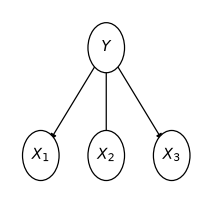

In [9]:
ax = draw_dag(nb_edges)
ax.figure.savefig("fig_nb_dag.pdf", bbox_inches="tight")
print("free parameters:", free_parameters(nb_edges))

### B2.2–B2.3

By hand; reproduced in B2.4.

### B2.4 Reproduce steps 2 and 3 in software, then repeat with the default settings

In [10]:
# step 2: posterior Dirichlet = BDeu pseudo-counts alpha_ijk + counts N_ijk, both taken from
# pgmpy (DiscreteBayesianEstimator normalises this sum into the fitted CPD)
nb_model = quiet(bn.make_DAG, nb_edges)["model"]
for i, node in enumerate(["Y", "X1", "X2", "X3"], start=1):
    prior, parents, _, _ = DiscreteBayesianEstimator._resolve_pseudo_counts(
        nb_model, STATES, node, "BDeu", ALPHA, None)
    counts = get_state_counts(data=data, state_names=STATES, variable=node, parents=parents)
    posterior = counts.to_numpy() + prior
    if not parents:
        print(f"{'theta_' + str(i):<9}{node:<12}prior {dir_str(prior[:, 0]):<15}"
              f"posterior {dir_str(posterior[:, 0])}")
    for j, cls in enumerate(STATES["Y"] if parents else []):
        print(f"{'theta_' + str(i) + str(j + 1):<9}{node + ' | Y = ' + cls:<12}"
              f"prior {dir_str(prior[:, j]):<15}posterior {dir_str(posterior[:, j])}")

theta_1  Y           prior Dir(4, 4, 4)   posterior Dir(337, 384, 168)
theta_21 X1 | Y = A  prior Dir(2, 2)      posterior Dir(205, 132)
theta_22 X1 | Y = B  prior Dir(2, 2)      posterior Dir(135, 249)
theta_23 X1 | Y = C  prior Dir(2, 2)      posterior Dir(114, 54)
theta_31 X2 | Y = A  prior Dir(2, 2)      posterior Dir(198, 139)
theta_32 X2 | Y = B  prior Dir(2, 2)      posterior Dir(244, 140)
theta_33 X2 | Y = C  prior Dir(2, 2)      posterior Dir(106, 62)
theta_41 X3 | Y = A  prior Dir(2, 2)      posterior Dir(163, 174)
theta_42 X3 | Y = B  prior Dir(2, 2)      posterior Dir(176, 208)
theta_43 X3 | Y = C  prior Dir(2, 2)      posterior Dir(93, 75)


In [11]:
# step 3: fit at alpha = 12 through pgmpy, classify the customer with bnlearn
DAG = quiet(bn.make_DAG, nb_edges)
DAG["model"].fit(data, estimator=DiscreteBayesianEstimator(
    prior_type="BDeu", equivalent_sample_size=ALPHA))
query_12 = quiet(bn.inference.fit, DAG, variables=["Y"], evidence=PROFILE)
print(query_12.df.round(4).to_string(index=False))

Y      p
A 0.2841
B 0.6080
C 0.1079


In [12]:
# default settings: bnlearn hard-codes equivalent_sample_size=1000
default_fit = quiet(bn.parameter_learning.fit, quiet(bn.make_DAG, nb_edges), data,
                    methodtype="bayes")
query_default = quiet(bn.inference.fit, default_fit, variables=["Y"], evidence=PROFILE)
print(query_default.df.round(4).to_string(index=False))

Y      p
A 0.3118
B 0.4704
C 0.2179


## B3 Prior sensitivity

In [13]:
alphas = [1, 12, 100, 1000]
sensitivity = {}
for a in alphas:
    dag_a = quiet(bn.make_DAG, nb_edges)
    dag_a["model"].fit(data, estimator=DiscreteBayesianEstimator(
        prior_type="BDeu", equivalent_sample_size=a))
    query_a = quiet(bn.inference.fit, dag_a, variables=["Y"], evidence=PROFILE)
    sensitivity[a] = query_a.df.set_index("Y")["p"]

sensitivity = pd.DataFrame(sensitivity).T.round(4)
sensitivity.index.name = "alpha"
sensitivity

Y,A,B,C
alpha,,,
1,0.2834,0.6111,0.1055
12,0.2841,0.6080,0.1079
100,0.2888,0.5855,0.1257
1000,0.3118,0.4704,0.2179


## B4 Five candidate classifiers

## Part A: function examples

### DAGs and factorization

In [14]:
nb_learned = quiet(bn.structure_learning.fit, data, methodtype="nb", root_node="Y")
print("structure_learning.fit(methodtype='nb'):", nb_learned["model_edges"])

for name, edges in M_EDGES.items():
    print(f"{name}: {free_parameters(edges):2d} free parameters")

structure_learning.fit(methodtype='nb'): [('Y', 'X1'), ('Y', 'X2'), ('Y', 'X3')]
M1: 23 free parameters
M2: 11 free parameters
M3: 14 free parameters
M4: 14 free parameters
M5: 14 free parameters


### Parameter learning

In [15]:
# "ml" gives N_ijk / N_ij: compare the fitted p(X1 | Y) with the count ratios
ml_fit = quiet(bn.parameter_learning.fit, quiet(bn.make_DAG, nb_edges), data, methodtype="ml")
cpd_tables = quiet(bn.print_CPD, ml_fit)
ml_x1 = cpd_tables["X1"].pivot(index="X1", columns="Y", values="p")
counts_x1 = pd.crosstab(data["Y"], data["X1"], normalize="index").T
print(ml_x1.round(6).to_string())
print(counts_x1.round(6).to_string())

Y           A     B         C
X1                           
high  0.39039  0.65  0.317073
low   0.60961  0.35  0.682927
Y           A     B         C
X1                           
low   0.60961  0.35  0.682927
high  0.39039  0.65  0.317073


### Classification probabilities

### Marginal likelihood